# Calibrated Explanations: SHAP Plugin Example

This notebook demonstrates how to use the official.explanation.factual.shap plugin with the calibrated-explanations library.
The SHAP plugin provides local SHAP-based feature attributions in the calibrated explanation flow.

In [20]:
import os
import sys
import importlib
from pathlib import Path

import numpy as np
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from calibrated_explanations import WrapCalibratedExplainer
import calibrated_explanations.plugins.registry as registry

# Trust the SHAP plugin for this session.
os.environ["CE_TRUST_PLUGIN"] = "official.explanation.factual.shap,ce_explanation_factual_shap.plugin:FactualShapExplanationPlugin"
# Prefer SHAP plugin for factual mode by default.
os.environ["CE_EXPLANATION_FACTUAL_PLUGIN"] = "official.explanation.factual.shap"

# Ensure notebook imports the local plugin source from this repo.
plugin_src = Path.cwd().parent / "src"
if not plugin_src.exists():
    raise RuntimeError(f"Expected local plugin source folder not found: {plugin_src}")
if str(plugin_src) not in sys.path:
    sys.path.insert(0, str(plugin_src))

# Force local module import/reload and show the concrete file being used.
if "ce_explanation_factual_shap.plugin" in sys.modules:
    plugin_module = importlib.reload(sys.modules["ce_explanation_factual_shap.plugin"])
else:
    plugin_module = importlib.import_module("ce_explanation_factual_shap.plugin")
print("Loaded plugin module:", plugin_module.__file__)

# Reset explanation catalog only, keep other registries intact.
if hasattr(registry, "reset_plugin_catalog"):
    registry.reset_plugin_catalog(kind="explanation")
if hasattr(registry, "clear_env_trust_cache"):
    registry.clear_env_trust_cache()
if hasattr(registry, "clear_trust_warnings"):
    registry.clear_trust_warnings()

# Explicitly register + trust local class so we cannot silently fall back.
plugin_cls = plugin_module.FactualShapExplanationPlugin
desc = registry.find_explanation_descriptor("official.explanation.factual.shap")
if desc is None:
    registry.register_explanation_plugin(
        "official.explanation.factual.shap",
        plugin_cls(),
        source="notebook-local",
    )
    registry.mark_explanation_trusted("official.explanation.factual.shap")
    desc = registry.find_explanation_descriptor("official.explanation.factual.shap")

if desc is None or not desc.trusted:
    raise RuntimeError("SHAP plugin is not loaded and trusted; refusing to continue.")

print("Plugin descriptor loaded:", desc is not None)
print("Plugin descriptor trusted:", getattr(desc, "trusted", None))
print("Plugin class:", desc.plugin.__class__.__name__)
print("Plugin class module:", desc.plugin.__class__.__module__)

Loaded plugin module: c:\Users\loftuw\Documents\Github\calibrated-explanations-plugins\packages\explanation\calibrated-explanations-explanation-factual-shap\src\ce_explanation_factual_shap\plugin.py
Plugin descriptor loaded: True
Plugin descriptor trusted: True
Plugin class: FactualShapExplanationPlugin
Plugin class module: ce_explanation_factual_shap.plugin


## Setup Data and Model
We'll create a synthetic classification dataset and train a Random Forest model.

In [21]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_proper, X_calib, y_proper, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

model = WrapCalibratedExplainer(RandomForestClassifier(n_estimators=100, random_state=42))
model.fit(X_proper, y_proper)

WrapCalibratedExplainer(learner=RandomForestClassifier(random_state=42), fitted=True, calibrated=False)

## Initialize Calibrated Explainer
Create a `CalibratedExplainer` and specify the LIME plugin.

In [22]:
import types

model.calibrate(X_calib, y_calib)

# Compatibility shim: route per-call plugin=... to factual plugin override.
_original_explain_factual = model.explain_factual


def _explain_factual_with_plugin(self, x, plugin=None, **kwargs):
    if plugin is not None:
        pm = self.explainer.plugin_manager
        pm.explanation_plugin_overrides["factual"] = plugin
        pm.clear_explanation_plugin_instances()
        pm.clear_explanation_plugin_identifiers()
        pm.initialize_chains()
    return _original_explain_factual(x, **kwargs)


model.explain_factual = types.MethodType(_explain_factual_with_plugin, model)
print("Installed explain_factual(plugin=...) compatibility shim")

Installed explain_factual(plugin=...) compatibility shim


## Generate SHAP Factual Explanations

Run the SHAP plugin and verify that rule labels are feature names (no condition operators)
and that lower/upper SHAP attribution vectors are present.

First rule labels: ['0', '1', '2', '3', '4']
Contains condition operators? False
SHAP metadata: {}
Has lower/upper SHAP weights: True
Sample center/lower/upper weight: -0.007313492063492154 -0.012122356264929746 -0.02115403056554676


C:\Users\loftuw\Documents\Github\kristinebergs-calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\kristinebergs-calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\kristinebergs-calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


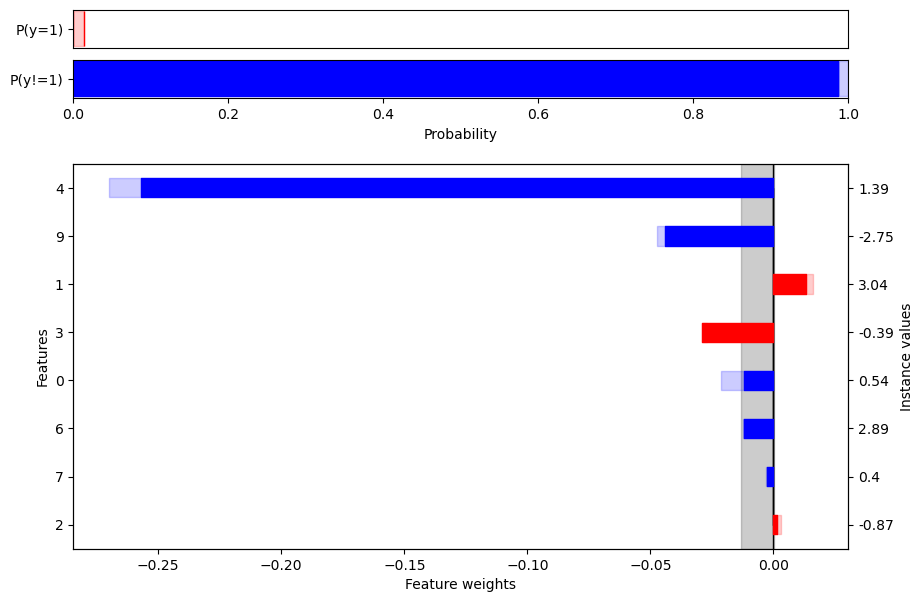

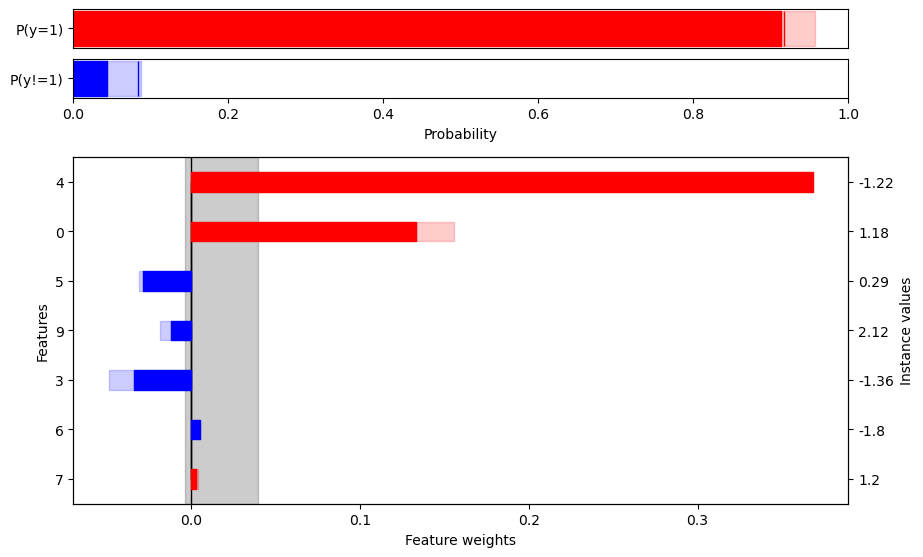

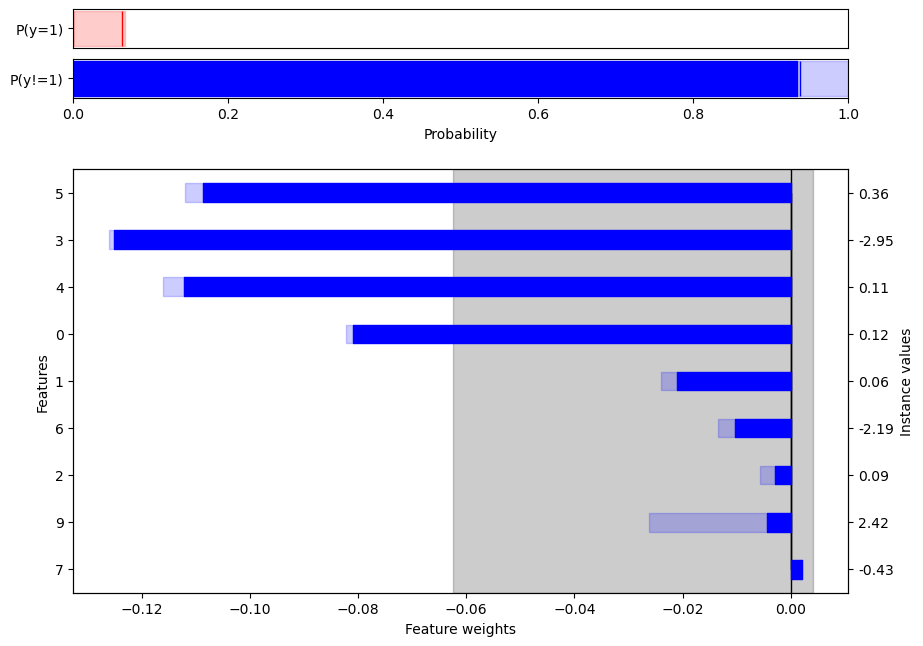

In [23]:
instances = X_test[:3]

# Direct plugin request.
explanations = model.explain_factual(instances, plugin="official.explanation.factual.shap")

rules0 = explanations.explanations[0].get_rules()
first_labels = rules0["rule"][:5]
contains_condition_ops = any(("<" in label or ">" in label or "=" in label) for label in first_labels)

meta_fn = getattr(explanations, "collection_metadata", None)
collection_meta = meta_fn() if callable(meta_fn) else {}
shap_meta = collection_meta.get("shap", {}) if isinstance(collection_meta, dict) else {}

print("First rule labels:", first_labels)
print("Contains condition operators?", contains_condition_ops)
print("SHAP metadata:", shap_meta)
print("Has lower/upper SHAP weights:", "weight_low" in rules0 and "weight_high" in rules0)
print("Sample center/lower/upper weight:", rules0["weight"][0], rules0["weight_low"][0], rules0["weight_high"][0])

# Visualize the generated explanations.
explanations.plot(uncertainty=True)